# Hoja de Trabajo 5


## Imports

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

RNG_SEED = 42


## Task 3

### Task 3.1 — Generación de redes sintéticas y métricas comparativas

In [2]:
N = 500

# Red aleatoria Erdos-Renyi: N=500, p=0.02
G_er = nx.erdos_renyi_graph(n=N, p=0.02, seed=RNG_SEED)

# Red libre de escala Barabasi-Albert: N=500, m=5
G_ba = nx.barabasi_albert_graph(n=N, m=5, seed=RNG_SEED)

# Red de mundo pequeno Watts-Strogatz: N=500, k=6, p=0.1
G_ws = nx.watts_strogatz_graph(n=N, k=6, p=0.1, seed=RNG_SEED)

redes = {
    "Erdos-Renyi (aleatoria)": G_er,
    "Barabasi-Albert (libre de escala)": G_ba,
    "Watts-Strogatz (mundo pequeno)": G_ws,
}


In [3]:
def calcular_metricas(G):
    grados = np.array([d for _, d in G.degree()])
    k_mean = grados.mean()
    k2_mean = (grados ** 2).mean()

    C_mean = nx.average_clustering(G)

    # Si la red no es conexa, <d> se calcula sobre el componente conexo mas grande
    if nx.is_connected(G):
        d_mean = nx.average_shortest_path_length(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        d_mean = nx.average_shortest_path_length(G.subgraph(largest_cc))

    # (beta/gamma)_c = <k> / (<k^2> - <k>)  -- condicion de Molloy-Reed
    umbral_critico = k_mean / (k2_mean - k_mean)

    return {
        "<k>": k_mean,
        "<k^2>": k2_mean,
        "<C>": C_mean,
        "<d>": d_mean,
        "(beta/gamma)_critico": umbral_critico,
    }

resultados = {nombre: calcular_metricas(G) for nombre, G in redes.items()}

print(f"{'Red':35s} {'<k>':>8s} {'<k^2>':>10s} {'<C>':>8s} {'<d>':>8s} {'(b/g)_c':>10s}")
print("-" * 82)
for nombre, m in resultados.items():
    print(f"{nombre:35s} {m['<k>']:8.3f} {m['<k^2>']:10.3f} {m['<C>']:8.4f} "
          f"{m['<d>']:8.3f} {m['(beta/gamma)_critico']:10.5f}")


Red                                      <k>      <k^2>      <C>      <d>    (b/g)_c
----------------------------------------------------------------------------------
Erdos-Renyi (aleatoria)                9.748    104.216   0.0161    2.967    0.10319
Barabasi-Albert (libre de escala)      9.900    203.112   0.0790    2.731    0.05124
Watts-Strogatz (mundo pequeno)         6.000     36.488   0.4645    5.697    0.19680


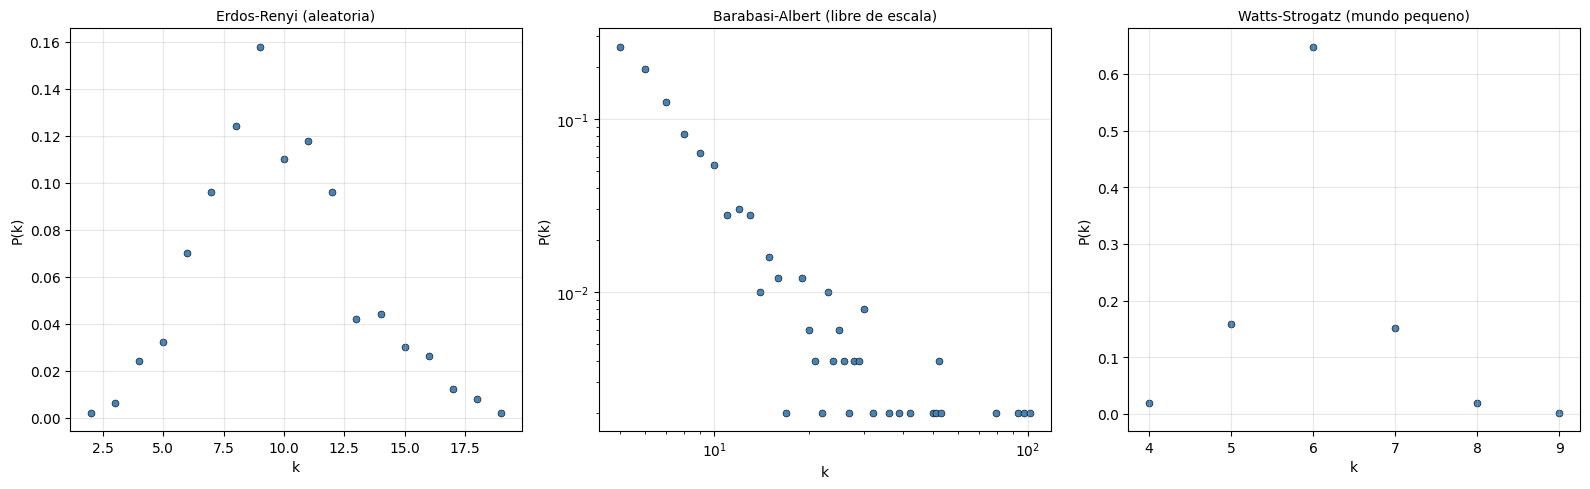

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, G) in zip(axes, redes.items()):
    grados = np.array([d for _, d in G.degree()])
    grado_counts = Counter(grados)
    ks = np.array(sorted(grado_counts.keys()))
    pk = np.array([grado_counts[k] for k in ks]) / G.number_of_nodes()

    ax.scatter(ks, pk, s=25, color="steelblue", edgecolor="black", linewidth=0.4)
    ax.set_xlabel("k")
    ax.set_ylabel("P(k)")
    ax.set_title(nombre, fontsize=10)
    ax.grid(True, alpha=0.3)

    if "Barabasi" in nombre:
        ax.set_xscale("log")
        ax.set_yscale("log")

plt.tight_layout()
plt.savefig("degree_distributions.png", dpi=150)
plt.show()


### Task 3.2 — Simulación de un proceso SIR sobre las tres redes

- Cada nodo infectado $I$ intenta contagiar, de forma independiente, a **cada uno de sus vecinos
  susceptibles** con probabilidad $\beta$ (por arista, por paso de tiempo).
- Cada nodo infectado se recupera con probabilidad $\gamma$ (por paso de tiempo), pasando a $R$.

Esta es la contraparte estocástica y basada en la topología real de la ecuación de campo medio vista en
clase,

$$\frac{dI}{dt} = \beta \langle k \rangle \frac{S}{N} I - \gamma I,$$

con la diferencia clave de que aquí el contagio solo ocurre a través de **aristas que realmente existen**
en cada red — por eso el resultado depende de $\langle k^2 \rangle$ y de la estructura (clustering,
distancia) de cada topología, y no solo de $\langle k \rangle$.

Parámetros: $\beta = 0.04$ por arista por paso de tiempo, $\gamma = 0.03$ por paso de tiempo, 5 nodos
infectados iniciales elegidos al azar, resto susceptibles. Nótese que $\beta/\gamma = 1.333$, muy por
encima del umbral crítico $(\beta/\gamma)_c$ calculado en el Task 3.1 para las tres redes (0.051–0.197),
por lo que se espera que la epidemia se propague en los tres casos.


In [ ]:
def simular_sir(G, beta, gamma, n_iniciales=5, rng=None):
    """Simulacion SIR de tiempo discreto sobre la red G.
    """
    if rng is None:
        rng = np.random.default_rng()

    nodes = list(G.nodes())
    N = len(nodes)
    estado = {n: "S" for n in nodes}
    iniciales = rng.choice(nodes, size=n_iniciales, replace=False)
    for n in iniciales:
        estado[n] = "I"

    infectados = set(iniciales)
    S_t = [N - len(infectados)]
    I_t = [len(infectados)]
    R_t = [0]

    while infectados:
        nuevos_infectados = set()
        nuevos_recuperados = set()
        for n in infectados:
            for vecino in G.neighbors(n):
                if estado[vecino] == "S" and rng.random() < beta:
                    nuevos_infectados.add(vecino)
            if rng.random() < gamma:
                nuevos_recuperados.add(n)

        for n in nuevos_infectados:
            estado[n] = "I"
        for n in nuevos_recuperados:
            estado[n] = "R"

        infectados = (infectados - nuevos_recuperados) | nuevos_infectados

        conteo = Counter(estado.values())
        S_t.append(conteo.get("S", 0))
        I_t.append(conteo.get("I", 0))
        R_t.append(conteo.get("R", 0))

    return np.array(S_t), np.array(I_t), np.array(R_t)


In [6]:
BETA, GAMMA = 0.04, 0.03
N_REALIZACIONES = 50
N_INICIALES = 5

# sir_resultados[nombre] = lista de 50 tuplas (S_t, I_t, R_t), una por realizacion
sir_resultados = {}
for idx, (nombre, G) in enumerate(redes.items()):
    corridas = []
    for i in range(N_REALIZACIONES):
        rng = np.random.default_rng(10_000 * idx + i)  # semilla reproducible por corrida
        corridas.append(simular_sir(G, BETA, GAMMA, N_INICIALES, rng=rng))
    sir_resultados[nombre] = corridas

print("Simulaciones completadas:", {n: len(c) for n, c in sir_resultados.items()})


Simulaciones completadas: {'Erdos-Renyi (aleatoria)': 50, 'Barabasi-Albert (libre de escala)': 50, 'Watts-Strogatz (mundo pequeno)': 50}


**a. Tamaño final del brote (fracción de la población) — media e intervalo de confianza del 95%**

In [7]:
resumen_sir = {}
for nombre, corridas in sir_resultados.items():
    tamanos_finales = np.array([R_t[-1] / N for _, _, R_t in corridas])
    media = tamanos_finales.mean()
    sem = tamanos_finales.std(ddof=1) / np.sqrt(len(tamanos_finales))
    ci95 = 1.96 * sem
    resumen_sir[nombre] = {
        "media": media,
        "ci95_low": media - ci95,
        "ci95_high": media + ci95,
        "std": tamanos_finales.std(ddof=1),
        "tamanos": tamanos_finales,
    }

print(f"{'Red':35s} {'media':>8s} {'IC95% inf':>10s} {'IC95% sup':>10s} {'std':>8s}")
print("-" * 75)
for nombre, r in resumen_sir.items():
    print(f"{nombre:35s} {r['media']:8.4f} {r['ci95_low']:10.4f} {r['ci95_high']:10.4f} {r['std']:8.4f}")


Red                                    media  IC95% inf  IC95% sup      std
---------------------------------------------------------------------------
Erdos-Renyi (aleatoria)               0.9974     0.9969     0.9979   0.0019
Barabasi-Albert (libre de escala)     0.9946     0.9936     0.9957   0.0038
Watts-Strogatz (mundo pequeno)        0.9835     0.9794     0.9876   0.0148


**b. Trayectorias $I(t)/N$ de las 50 realizaciones por red (línea gruesa = media)**

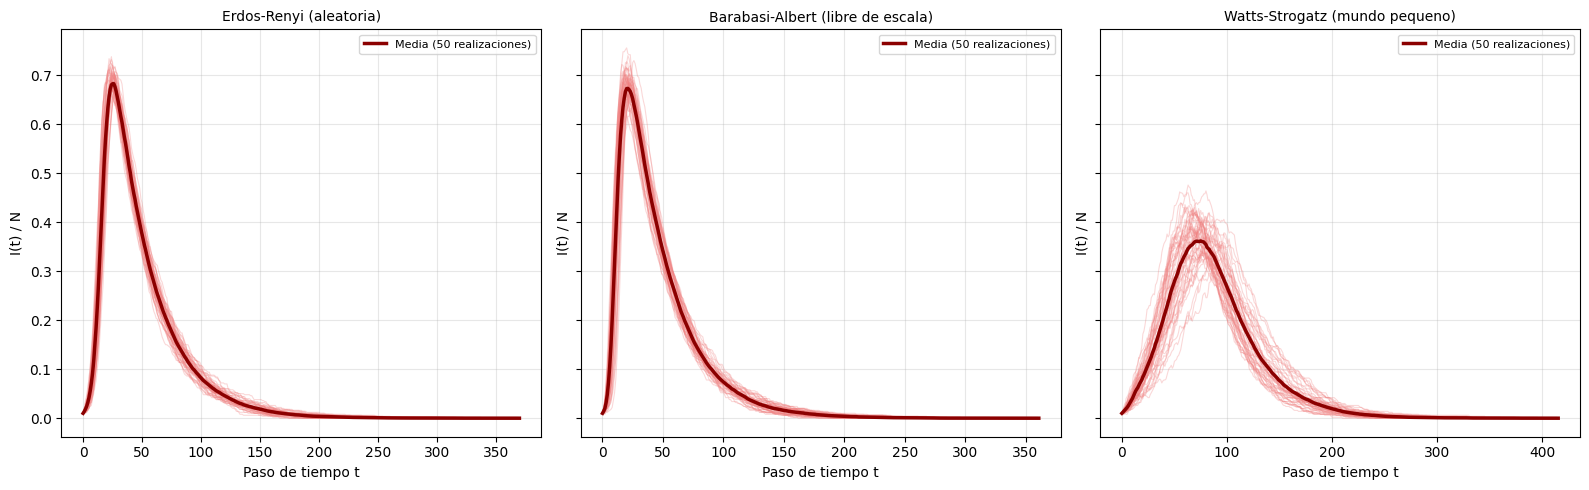

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (nombre, corridas) in zip(axes, sir_resultados.items()):
    max_t = max(len(I_t) for _, I_t, _ in corridas)
    trayectorias = np.zeros((len(corridas), max_t))
    for i, (_, I_t, _) in enumerate(corridas):
        trayectorias[i, :len(I_t)] = I_t / N
        # tras extinguirse el brote I=0; el resto del arreglo ya quedo en 0

    for fila in trayectorias:
        ax.plot(fila, color="lightcoral", alpha=0.3, linewidth=0.8)

    media_t = trayectorias.mean(axis=0)
    ax.plot(media_t, color="darkred", linewidth=2.5, label="Media (50 realizaciones)")

    ax.set_xlabel("Paso de tiempo t")
    ax.set_ylabel("I(t) / N")
    ax.set_title(nombre, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sir_trajectories.png", dpi=150)
plt.show()
